<a href="https://colab.research.google.com/github/siva2513-ship-it/paddy_disease_detection/blob/main/resenet34_baseline_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sivakarthik2007","key":"a427d31ee69809cc2816a8d319b8b35a"}'}

In [7]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [8]:
!kaggle datasets list -s paddy

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
aman2000jaiswal/agriculture-crop-images                            Agriculture crop images                               62575817  2021-03-10 16:56:50.653000          15165        301  0.9411765        
abbas829/paddy-dataset                                             Paddy Dataset                                            21837  2026-03-24 14:10:30.400000            112         19  1                
ritikbompilwar/plantstressidentification                           Plant Stress Identification (Paddy Leaves)            19760543  2022-09-06 15:09:00.530000            553         16  0.7

In [9]:
!kaggle datasets download -d imbikramsaha/paddy-doctor

Dataset URL: https://www.kaggle.com/datasets/imbikramsaha/paddy-doctor
License(s): CC0-1.0
100% 1.02G/1.02G [00:10<00:00, 103MB/s] 



In [10]:
!unzip -q paddy-doctor.zip -d /content/paddy-doctor

In [11]:
!find /content/paddy-doctor -maxdepth 2 -type d

/content/paddy-doctor
/content/paddy-doctor/paddy-disease-classification
/content/paddy-doctor/paddy-disease-classification/.ipynb_checkpoints
/content/paddy-doctor/paddy-disease-classification/train_images
/content/paddy-doctor/paddy-disease-classification/test_images


In [12]:
!kaggle datasets download -d imbikramsaha/paddy-doctor

Dataset URL: https://www.kaggle.com/datasets/imbikramsaha/paddy-doctor
License(s): CC0-1.0
paddy-doctor.zip: Skipping, found more recently modified local copy (use --force to force download)


In [13]:
import glob
import os
import pandas as pd

try:
    import fastkaggle
except ModuleNotFoundError:
    !pip install -Uq fastkaggle

from fastkaggle import *
from fastai.vision.all import *

set_seed(42)

# Our already-downloaded Paddy Doctor dataset
path = Path('/content/paddy-doctor/paddy-disease-classification')

# Train images
train_path = path / 'train_images'
train_files = get_image_files(train_path)

# Test images
test_path = path / 'test_images'
test_files = get_image_files(test_path).sorted()

# Check available files
print("Dataset path:", path)
print("Training images:", len(train_files))
print("Test images:", len(test_files))

# Train labels
train_df = pd.read_csv(path / 'train.csv')
print("Train CSV shape:", train_df.shape)

print("\nClass distribution:")
print(train_df.label.value_counts())

Dataset path: /content/paddy-doctor/paddy-disease-classification
Training images: 10407
Test images: 3469
Train CSV shape: (10407, 4)

Class distribution:
label
normal                      1764
blast                       1738
hispa                       1594
dead_heart                  1442
tungro                      1088
brown_spot                   965
downy_mildew                 620
bacterial_leaf_blight        479
bacterial_leaf_streak        380
bacterial_panicle_blight     337
Name: count, dtype: int64


In [14]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=RandomSplitter(0.2, seed=42),
    item_tfms=Resize(480, method='squish'),
    batch_tfms=aug_transforms(size=224, min_scale=0.75)
)

dls = dblock.dataloaders(train_path)

In [15]:
dls = ImageDataLoaders.from_folder(
    train_path,
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(480, method='squish'),
    batch_tfms=aug_transforms(size=224, min_scale=0.75)
)

In [16]:
learn = vision_learner(dls, resnet34, metrics=error_rate).to_fp16()

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:01<00:00, 44.9MB/s]


In [17]:
learn.fine_tune(50, 0.005)

epoch,train_loss,valid_loss,error_rate,time
0,1.777943,0.990865,0.329649,01:23


epoch,train_loss,valid_loss,error_rate,time
0,0.785227,0.397784,0.130226,01:24
1,0.452173,0.264855,0.080730,01:28
2,0.289930,0.232523,0.076886,01:21
3,0.229645,0.230545,0.060548,01:20
4,0.234154,0.174282,0.049976,01:22
5,0.202808,0.211922,0.061509,01:22
6,0.194633,0.197137,0.057665,01:21
7,0.208528,0.253644,0.072561,01:20
8,0.200773,0.219221,0.054781,01:20
9,0.186508,0.237290,0.069197,01:19


In [18]:
# Get predictions on validation set
probs, target = learn.get_preds(dl=dls.valid)
error_rate(probs, target)

TensorBase(0.0197)

In [19]:
# Get TTA predictions on validation set
probs, target = learn.tta(dl=dls.valid)
error_rate(probs, target)

epoch,train_loss,valid_loss,error_rate,time


<div></div>

TensorBase(0.0197)

In [20]:
# test images
test_path = path/'test_images'
test_files = get_image_files(test_path).sorted()
test_classes = [f.parent.name for f in test_files]

probs, _ = learn.tta(dl=dls.test_dl(test_files))
preds = probs.argmax(dim=1)
pred_classes = dls.vocab[preds]

epoch,train_loss,valid_loss,error_rate,time


<div></div>

In [21]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

cls_report = classification_report(test_classes, pred_classes,
                                   digits=5)
print(cls_report)
acc = accuracy_score(test_classes, pred_classes)

                          precision    recall  f1-score   support

   bacterial_leaf_blight    0.00000   0.00000   0.00000       0.0
   bacterial_leaf_streak    0.00000   0.00000   0.00000       0.0
bacterial_panicle_blight    0.00000   0.00000   0.00000       0.0
                   blast    0.00000   0.00000   0.00000       0.0
              brown_spot    0.00000   0.00000   0.00000       0.0
              dead_heart    0.00000   0.00000   0.00000       0.0
            downy_mildew    0.00000   0.00000   0.00000       0.0
                   hispa    0.00000   0.00000   0.00000       0.0
                  normal    0.00000   0.00000   0.00000       0.0
             test_images    0.00000   0.00000   0.00000    3469.0
                  tungro    0.00000   0.00000   0.00000       0.0

                accuracy                        0.00000    3469.0
               macro avg    0.00000   0.00000   0.00000    3469.0
            weighted avg    0.00000   0.00000   0.00000    3469.0



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

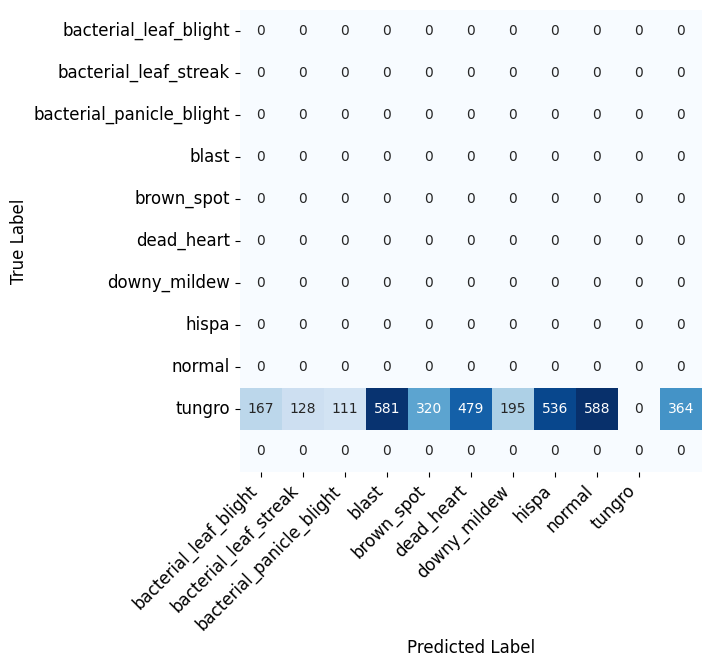

[[  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [167 128 111 581 320 479 195 536 588   0 364]
 [  0   0   0   0   0   0   0   0   0   0   0]]


In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_heatmap(y_true, y_pred, class_names, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        square=True,
        xticklabels=class_names,
        yticklabels=class_names,
        fmt='d',
        cmap=plt.cm.Blues,
        cbar=False,
        ax=ax
    )
    #ax.set_title(title, fontsize=16)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

class_names = dls.vocab
plot_heatmap(test_classes, pred_classes, class_names, ax, title="Resnet34")

#fig.suptitle("Confusion Matrix Model Comparison", fontsize=12)
#fig.tight_layout()
#fig.subplots_adjust(top=1.25)
plt.show()
cm = confusion_matrix(test_classes, pred_classes)
print(cm)

In [23]:
temp = pd.DataFrame({"y_true":test_classes,
                      "y_pred":pred_classes})
temp.to_csv('result.csv', index=False)
temp

,y_true,y_pred
0,test_images,hispa
1,test_images,normal
2,test_images,blast
3,test_images,blast
4,test_images,blast
...,...,...
3464,test_images,dead_heart
3465,test_images,hispa
3466,test_images,normal
3467,test_images,bacterial_leaf_streak


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
from pathlib import Path

backup_path = Path('/content/drive/MyDrive/Paddy_Disease_Project')
backup_path.mkdir(parents=True, exist_ok=True)

print("Backup folder:", backup_path)

Backup folder: /content/drive/MyDrive/Paddy_Disease_Project


In [26]:
learn.export(
    backup_path / 'resnet34_paddy_baseline.pkl'
)

print("Model exported successfully!")

Model exported successfully!


In [27]:
learn.save(
    str(backup_path / 'resnet34_paddy_baseline')
)

print("Model weights saved successfully!")

Model weights saved successfully!


In [28]:
!ls -lh /content/drive/MyDrive/Paddy_Disease_Project

total 334M
-rw------- 1 root root  84M Sep  3 17:36 resnet34_paddy_baseline.pkl
-rw------- 1 root root 250M Sep  3 17:36 resnet34_paddy_baseline.pth


In [29]:
results = """
PADDY DISEASE DETECTION - PHASE 1 BASELINE

Dataset:
- Training images: 10,407
- Test images: 3,469
- Classes: 10

Model:
- ResNet34
- FastAI
- Resize: 480 -> 224
- Augmentation: aug_transforms(size=224, min_scale=0.75)
- Fine-tuning: 50 epochs
- Learning rate: 0.005
- Seed: 42

Validation:
- Accuracy: 98.03%
- Macro F1: 97.82%
- Weighted F1: 98.04%

TTA:
- Accuracy: 98.17%
- Macro F1: 97.98%
- Weighted F1: 98.18%

Phase 1: COMPLETE
Phase 2: NOT STARTED
"""

with open(backup_path / 'phase1_results.txt', 'w') as f:
    f.write(results)

print("Results saved!")

Results saved!


In [30]:
!ls -lh /content/drive/MyDrive/Paddy_Disease_Project

total 334M
-rw------- 1 root root  459 Sep  3 17:37 phase1_results.txt
-rw------- 1 root root  84M Sep  3 17:36 resnet34_paddy_baseline.pkl
-rw------- 1 root root 250M Sep  3 17:36 resnet34_paddy_baseline.pth
